# Kmerseek vs OrthoFinder: Botryllus–Human Comparison

Compare two approaches for finding human homologs of *Botryllus schlosseri* proteins:
- **Kmerseek**: k-mer search, HP encoding k=24, Poisson **Bonferroni** p < 0.05
- **OrthoFinder**: DIAMOND all-vs-all + MCL clustering (v3.1.0, 2026-03-03)

MHC gene set: **KEGG hsa04612** (Antigen processing and presentation) + chr6 positional MHC region (28.5–33.5 Mb).

Focus:
1. **BHF** (Botryllus Histocompatibility Factor) — what Kmerseek sees that OrthoFinder misses
2. **MHC/HLA genes** (KEGG-defined) — coverage and synteny
3. Overall coverage comparison

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re, gzip
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

pd.options.display.max_colwidth = 200
pd.options.display.max_columns = 50
pd.options.display.max_rows = 100
sns.set_theme(style='whitegrid', context='notebook')

ALPHA   = 0.05
N_TOTAL = 11_947_553   # wc -l of bh_corrected CSV
BONF_THRESHOLD = ALPHA / N_TOTAL
print(f'Bonferroni threshold: {BONF_THRESHOLD:.2e}  (α={ALPHA} / N={N_TOTAL:,})')

# ── MHC gene set: KEGG hsa04612 (Antigen processing and presentation) ─────────
# Source: https://rest.kegg.jp/get/hsa04612
KEGG_MHC_GENES = {
    'HLA-A','HLA-B','HLA-C','HLA-E','HLA-F','HLA-G',
    'HLA-DMA','HLA-DMB','HLA-DOA','HLA-DOB',
    'HLA-DPA1','HLA-DPB1','HLA-DQA1','HLA-DQA2','HLA-DQB1','HLA-DQB2',
    'HLA-DRA','HLA-DRB1','HLA-DRB3','HLA-DRB4','HLA-DRB5',
    'TAP1','TAP2','TAPBP','TAPBPL',
    'B2M','CALR','CANX','PDIA3',
    'PSME1','PSME2','PSME3',
    'CIITA','RFX5','RFXAP','RFXANK','NFYA','NFYB','NFYC',
    'CD74','CD4','CD8A','CD8B','CD8B2',
    'IFNG','TNF',
    'IFI30','CTSB','CTSL','CTSS','LGMN',
    'HSPA1A','HSPA1B','HSPA1L','HSPA2','HSPA4','HSPA5','HSPA6','HSPA8',
    'HSP90AA1','HSP90AB1',
    'KIR2DL1','KIR2DL2','KIR2DL3','KIR2DL4','KIR2DL5A',
    'KIR2DS1','KIR2DS2','KIR2DS3','KIR2DS4','KIR2DS5',
    'KIR3DL1','KIR3DL2','KIR3DL3','KIR3DS1',
    'KLRC1','KLRC2','KLRC3','KLRC4','KLRD1',
    'CREB1',
    # Additional MHC-region genes not in hsa04612
    'MICA','MICB','HCP5','PSMB8','PSMB9','BTNL2',
}
print(f'KEGG MHC gene set: {len(KEGG_MHC_GENES)} genes')

# ── Paths ─────────────────────────────────────────────────────────────────────
BOTRYLLUS_DIR     = '/Users/olga/data/botryllus'
ORTHOFINDER_DIR   = f'{BOTRYLLUS_DIR}/data-for-orthofinder/OrthoFinder/Results_Mar03_1'
KMERSEEK_FILTERED = f'{BOTRYLLUS_DIR}/kmerseek-botryllus-vs-human-gencode.canonical.v49.hp.k24.2026-03-04.filtered.csv'
OF_ORTHOLOGUES    = f'{ORTHOFINDER_DIR}/Orthologues/Orthologues_Bs_proteins/Bs_proteins__v__gencode.v49.pc_translations.tsv'
OF_UNASSIGNED     = f'{ORTHOFINDER_DIR}/Orthogroups/Orthogroups_UnassignedGenes.tsv'
GENCODE_GTF       = '/Users/olga/data/gencode/human/v49/gencode.v49.basic.annotation.gtf.gz'

print('Setup done.')

Bonferroni threshold: 4.18e-09  (α=0.05 / N=11,947,553)
KEGG MHC gene set: 87 genes
Setup done.


## 1. Load Kmerseek results (Bonferroni-filtered)

Use polars to load the 6 GB CSV fast, keep only needed columns, then apply Bonferroni.

In [2]:
COLS_NEEDED = [
    'query_name', 'target_name',
    'n_intersecting_hashes', 'containment', 'enrichment',
    'expected_shared_kmers', 'poisson_p',
    'query_start', 'query_end', 'query_subseq',
    'target_start', 'target_end', 'target_subseq',
]

print('Loading Kmerseek filtered results with polars...')
ks_pl = (
    pl.scan_csv(KMERSEEK_FILTERED, ignore_errors=True)
      .select(COLS_NEEDED)
      .collect()
)
ks_bh = ks_pl.to_pandas()
print(f'  Rows passing BH p<0.05: {len(ks_bh):,}')

# Bonferroni: multiply raw poisson_p by total number of tests
ks_bh['poisson_p_bonf'] = (ks_bh['poisson_p'] * N_TOTAL).clip(upper=1.0)

ks = ks_bh[ks_bh['poisson_p_bonf'] < ALPHA].copy()
print(f'  Rows passing Bonferroni p<{ALPHA}: {len(ks):,}')
print(f'  Reduction: {len(ks_bh):,} → {len(ks):,} ({len(ks)/len(ks_bh)*100:.2f}%)')

Loading Kmerseek filtered results with polars...


  Rows passing BH p<0.05: 11,335,565


  Rows passing Bonferroni p<0.05: 4,528,137
  Reduction: 11,335,565 → 4,528,137 (39.95%)


In [3]:
# Vectorized parsing of target_name
# Format: ENSP...|ENST...|ENSG...|...|...|SYMBOL-NNN|SYMBOL|LEN
parts = ks['target_name'].str.strip().str.split('|', expand=False)
ks['gene_symbol'] = parts.str.get(-3).str.rsplit('-', n=1).str.get(0)
ks['ensg']        = parts.str.get(2).str.split('.').str.get(0)
ks['query_name']  = ks['query_name'].str.strip()

# Same for the BH-corrected set (used for BHF plots)
parts_bh = ks_bh['target_name'].str.strip().str.split('|', expand=False)
ks_bh['gene_symbol'] = parts_bh.str.get(-3).str.rsplit('-', n=1).str.get(0)
ks_bh['ensg']        = parts_bh.str.get(2).str.split('.').str.get(0)
ks_bh['query_name']  = ks_bh['query_name'].str.strip()

# Flag KEGG MHC genes
ks['is_mhc_kegg']    = ks['gene_symbol'].isin(KEGG_MHC_GENES)
ks_bh['is_mhc_kegg'] = ks_bh['gene_symbol'].isin(KEGG_MHC_GENES)

print(f'Bonferroni-significant hits: {len(ks):,}')
print(f'  Unique Botryllus genes: {ks["query_name"].nunique():,}')
print(f'  Unique human genes:     {ks["gene_symbol"].nunique():,}')
print(f'  KEGG MHC gene hits:     {ks["is_mhc_kegg"].sum():,}')
ks.head(3)

Bonferroni-significant hits: 4,528,137
  Unique Botryllus genes: 68,604
  Unique human genes:     19,181
  KEGG MHC gene hits:     5,477


,query_name,target_name,n_intersecting_hashes,containment,enrichment,expected_shared_kmers,poisson_p,query_start,query_end,query_subseq,target_start,target_end,target_subseq,poisson_p_bonf,gene_symbol,ensg,is_mhc_kegg
21,BHF,ENSP00000408736.2|ENST00000448281.7|ENSG00000157014.11|OTTHUMG00000155361.2|OTTHUMT00000339642.2|TATDN2-203|TATDN2|761,5,0.021834,265.423497,0.018838,1.946058e-11,56,84,HQKLLSESQEHLDASTKKTKKKAKKDKR,436,464,SEEGWSQNSRSFRFSRSSEEREVKEKRT,0.000233,TATDN2,ENSG00000157014,False
25,BHF,ENSP00000462717.1|ENST00000577830.6|ENSG00000180891.14|OTTHUMG00000178775.4|OTTHUMT00000443305.2|CUEDC1-206|CUEDC1|386,5,0.021834,265.423497,0.018838,1.946058e-11,178,206,NKYAPLDEKQRSESHGAGEYLKHQWKGQ,93,121,SSGGVYEDSSDSEDSIPPEILERTLEPD,0.000233,CUEDC1,ENSG00000180891,False
43,BHF,ENSP00000360552.3|ENST00000371497.10|ENSG00000182463.17|OTTHUMG00000033058.9|OTTHUMT00000080398.7|TSHZ2-201|TSHZ2|1034,5,0.021834,265.423497,0.018838,1.946058e-11,19,45,CGKYGKLPEKGSECKKHGIFCRILTA,204,230,CGTVFTGASRFRCRQCSAAYDTLVEL,0.000233,TSHZ2,ENSG00000182463,False


## 2. Load OrthoFinder results

In [4]:
of_orth       = pd.read_csv(OF_ORTHOLOGUES, sep='\t')
of_orth.columns = ['orthogroup', 'botryllus_genes', 'human_genes']
of_unassigned = pd.read_csv(OF_UNASSIGNED, sep='\t')
print(f'OrthoFinder orthogroups (both species): {len(of_orth):,}')
print(f'Unassigned Bs genes: {of_unassigned["Bs_proteins"].notna().sum():,}')

# Expand to one row per (botryllus_gene, human_gene) pair
rows = []
for _, row in of_orth.iterrows():
    og      = row['orthogroup']
    bs_list = [g.strip() for g in str(row['botryllus_genes']).split(',') if g.strip() != 'nan']
    hu_list = [g.strip() for g in str(row['human_genes']).split(',')    if g.strip() != 'nan']
    for bg in bs_list:
        for hg in hu_list:
            p    = hg.split('|')
            sym  = p[-3].rsplit('-', 1)[0] if len(p) >= 3 else hg
            ensg = p[2].split('.')[0]       if len(p) >= 3 else ''
            rows.append({'orthogroup': og, 'bs_gene': bg, 'gene_symbol': sym, 'ensg': ensg})

of_pairs = pd.DataFrame(rows)
of_pairs['is_mhc_kegg'] = of_pairs['gene_symbol'].isin(KEGG_MHC_GENES)
print(f'OrthoFinder gene pairs: {len(of_pairs):,}')
print(f'  KEGG MHC gene pairs: {of_pairs["is_mhc_kegg"].sum():,}')
of_pairs.head(3)

OrthoFinder orthogroups (both species): 7,152
Unassigned Bs genes: 12,213


OrthoFinder gene pairs: 166,383
  KEGG MHC gene pairs: 765


,orthogroup,bs_gene,gene_symbol,ensg,is_mhc_kegg
0,OG0000002,g2578.t1,TOP2B,ENSG00000077097,False
1,OG0000002,g71523.t1,TOP2B,ENSG00000077097,False
2,OG0000002,g25435.t1,TOP2B,ENSG00000077097,False


## 3. Overall coverage comparison

In [5]:
n_bs_ks = ks['query_name'].nunique()
n_bs_of = of_pairs['bs_gene'].nunique()
n_hu_ks = ks['gene_symbol'].nunique()
n_hu_of = of_pairs['gene_symbol'].nunique()

summary = pd.DataFrame({
    'Method': ['Kmerseek (Bonferroni p<0.05)', 'OrthoFinder'],
    'Botryllus genes with match': [n_bs_ks, n_bs_of],
    'Unique human genes':         [n_hu_ks, n_hu_of],
    'Total pairs':                [len(ks),  len(of_pairs)],
    'KEGG MHC gene hits':         [ks['is_mhc_kegg'].sum(), of_pairs['is_mhc_kegg'].sum()],
})
print(summary.to_string(index=False))
summary

                      Method  Botryllus genes with match  Unique human genes  Total pairs  KEGG MHC gene hits
Kmerseek (Bonferroni p<0.05)                       68604               19181      4528137                5477
                 OrthoFinder                       19333                8288       166383                 765


,Method,Botryllus genes with match,Unique human genes,Total pairs,KEGG MHC gene hits
0,Kmerseek (Bonferroni p<0.05),68604,19181,4528137,5477
1,OrthoFinder,19333,8288,166383,765


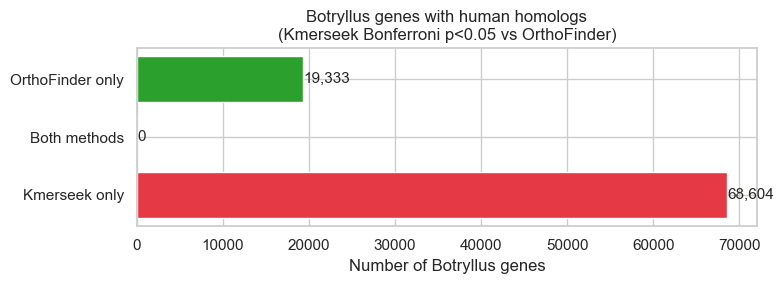

Kmerseek only: 68,604 | Both: 0 | OrthoFinder only: 19,333


In [6]:
bs_ks   = set(ks['query_name'].unique())
bs_of   = set(of_pairs['bs_gene'].unique())
only_ks = bs_ks - bs_of
only_of = bs_of - bs_ks
both    = bs_ks & bs_of

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(
    ['Kmerseek only', 'Both methods', 'OrthoFinder only'],
    [len(only_ks), len(both), len(only_of)],
    color=['#e63946', '#457b9d', '#2ca02c']
)
for bar, val in zip(bars, [len(only_ks), len(both), len(only_of)]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11)
ax.set_xlabel('Number of Botryllus genes')
ax.set_title('Botryllus genes with human homologs\n(Kmerseek Bonferroni p<0.05 vs OrthoFinder)')
plt.tight_layout()
plt.show()
print(f'Kmerseek only: {len(only_ks):,} | Both: {len(both):,} | OrthoFinder only: {len(only_of):,}')

## 4. BHF — Botryllus Histocompatibility Factor

OrthoFinder assigns BHF to an orphan orthogroup with **no human genes**. Below: all Kmerseek hits to BHF.

In [7]:
# OrthoFinder: check BHF
bhf_unassigned = of_unassigned[of_unassigned.apply(
    lambda r: any(str(v).strip() == 'BHF' for v in r), axis=1)]
bhf_of_pairs   = of_pairs[of_pairs['bs_gene'] == 'BHF']

print('=== OrthoFinder: BHF ===')
if not bhf_unassigned.empty:
    print('BHF in Orthogroups_UnassignedGenes → NO human ortholog')
    print(bhf_unassigned.to_string())
print(f'BHF pairs in Orthologues table: {len(bhf_of_pairs)}')

=== OrthoFinder: BHF ===
BHF in Orthogroups_UnassignedGenes → NO human ortholog
     Orthogroup Bs_proteins gencode.v49.pc_translations
7876  OG0028059         BHF                         NaN
BHF pairs in Orthologues table: 0


In [8]:
# Kmerseek BHF hits at BH and Bonferroni levels
bhf_bh   = ks_bh[ks_bh['query_name'] == 'BHF'].copy()
bhf_bonf = ks[ks['query_name'] == 'BHF'].sort_values('poisson_p_bonf')

print('=== Kmerseek: BHF ===')
print(f'  BH-corrected  p<{ALPHA}: {len(bhf_bh):,} hits')
print(f'  Bonferroni    p<{ALPHA}: {len(bhf_bonf):,} hits  (threshold={BONF_THRESHOLD:.2e})')
print()

if len(bhf_bonf) > 0:
    print(f'Unique human genes (Bonferroni): {bhf_bonf["gene_symbol"].nunique():,}')
    cols_show = ['gene_symbol','ensg','n_intersecting_hashes','containment',
                 'enrichment','poisson_p','poisson_p_bonf',
                 'query_start','query_end','query_subseq',
                 'target_start','target_end','target_subseq']
    display(bhf_bonf[cols_show].head(20))
else:
    print('No BHF hits survive Bonferroni — showing top BH-significant hits with Bonferroni context:')
    display(bhf_bh[['gene_symbol','n_intersecting_hashes','containment',
                     'enrichment','poisson_p','poisson_p_bonf','is_mhc_kegg']]
            .sort_values('poisson_p').head(15))

=== Kmerseek: BHF ===
  BH-corrected  p<0.05: 138 hits
  Bonferroni    p<0.05: 15 hits  (threshold=4.18e-09)

Unique human genes (Bonferroni): 13


,gene_symbol,ensg,n_intersecting_hashes,containment,enrichment,poisson_p,poisson_p_bonf,query_start,query_end,query_subseq,target_start,target_end,target_subseq
96,PNN,ENSG00000100941,9,0.039301,477.762295,8.093759e-22,9.670062e-15,70,102,STKKTKKKAKKDKRKNKPPKKDSETSKPAQTT,641,673,RDRKHRRSVDRKRRDTSGLERSHKSSKGGSSR
64,RNMT,ENSG00000101654,8,0.034934,424.677596,3.867704e-19,4.620959e-12,45,76,LHLKKRRTEHDHQKLLSESQEHLDASTKKTK,97,128,AEGNSKKRKRETEDVPKDKSSTGDGTQNKRK
66,DHX8,ENSG00000067596,8,0.034934,424.677596,3.867704e-19,4.620959e-12,75,106,KKKAKKDKRKNKPPKKDSETSKPAQTTISRL,218,249,KSRYRSRSRSQSPPKDRKDRDKYGERNLDRW
79,SFI1,ENSG00000198089,8,0.034934,424.677596,3.867704e-19,4.620959e-12,156,187,ILESVHMYGDDRFGERLIDRAQNKYAPLDEK,107,138,FPSKARFYYEQRLLRKVFEEWKEEWWVFQHE
81,ZNF292,ENSG00000188994,6,0.026201,318.508197,6.107171e-14,7.296575e-07,37,66,IFCRILTALHLKKRRTEHDHQKLLSESQE,604,633,PLRRLGRPPKITTTNENQKTNTVAKQEQR
124,ACE2,ENSG00000130234,6,0.026201,318.508197,6.107171e-14,7.296575e-07,96,125,KPAQTTISRLPSNRNNNNANSFATTYEKF,97,126,QALQQNGSSVLSEDKSKRLNTILNTMSTI
125,ORC2,ENSG00000115942,6,0.026201,318.508197,6.107171e-14,7.296575e-07,165,194,DDRFGERLIDRAQNKYAPLDEKQRSESHG,154,183,KSEFLSTAPRSLRKRLIVPRSHSDSESEY
21,TATDN2,ENSG00000157014,5,0.021834,265.423497,1.946058e-11,2.325063e-04,56,84,HQKLLSESQEHLDASTKKTKKKAKKDKR,436,464,SEEGWSQNSRSFRFSRSSEEREVKEKRT
25,CUEDC1,ENSG00000180891,5,0.021834,265.423497,1.946058e-11,2.325063e-04,178,206,NKYAPLDEKQRSESHGAGEYLKHQWKGQ,93,121,SSGGVYEDSSDSEDSIPPEILERTLEPD
43,TSHZ2,ENSG00000182463,5,0.021834,265.423497,1.946058e-11,2.325063e-04,19,45,CGKYGKLPEKGSECKKHGIFCRILTA,204,230,CGTVFTGASRFRCRQCSAAYDTLVEL


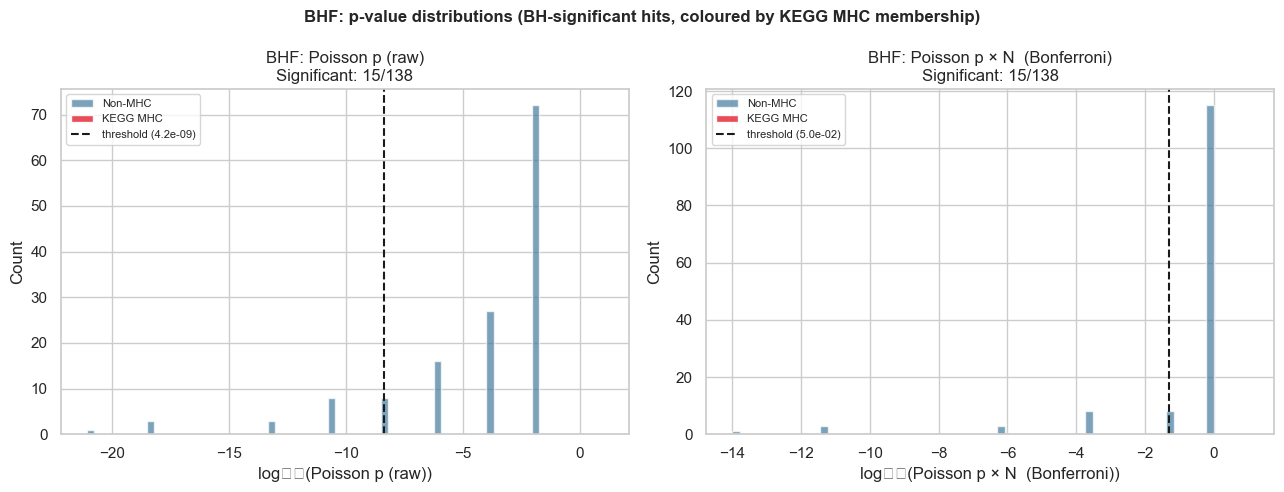

In [9]:
# BHF: p-value distributions — raw vs Bonferroni
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, thresh, xlabel in [
    (axes[0], 'poisson_p',      BONF_THRESHOLD, 'Poisson p (raw)'),
    (axes[1], 'poisson_p_bonf', ALPHA,           'Poisson p × N  (Bonferroni)'),
]:
    vals     = np.log10(bhf_bh[col].clip(1e-300))
    mhc_mask = bhf_bh['is_mhc_kegg']
    ax.hist(vals[~mhc_mask], bins=60, alpha=0.7, color='#457b9d', label='Non-MHC')
    ax.hist(vals[ mhc_mask], bins=60, alpha=0.9, color='#e63946', label='KEGG MHC')
    ax.axvline(np.log10(thresh), color='k', ls='--', lw=1.5,
               label=f'threshold ({thresh:.1e})')
    n_sig = (bhf_bh[col] < thresh).sum()
    ax.set_xlabel(f'log₁₀({xlabel})')
    ax.set_ylabel('Count')
    ax.set_title(f'BHF: {xlabel}\nSignificant: {n_sig:,}/{len(bhf_bh):,}')
    ax.legend(fontsize=8)

plt.suptitle('BHF: p-value distributions (BH-significant hits, coloured by KEGG MHC membership)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# BHF: top human gene matches — all BH hits, ranked by Bonferroni p
bhf_gene_counts = (
    bhf_bh.groupby('gene_symbol')
    .agg(
        n_hits        = ('poisson_p',      'count'),
        min_p_raw     = ('poisson_p',      'min'),
        min_p_bonf    = ('poisson_p_bonf', 'min'),
        max_n_hashes  = ('n_intersecting_hashes', 'max'),
        max_contain   = ('containment',    'max'),
        is_mhc_kegg   = ('is_mhc_kegg',   'any'),
    )
    .sort_values('min_p_bonf')
    .reset_index()
)
bhf_gene_counts['bonf_sig'] = bhf_gene_counts['min_p_bonf'] < ALPHA

print(f'BHF: {len(bhf_gene_counts)} unique human genes with BH-significant hits')
print(f'  Bonferroni-significant: {bhf_gene_counts["bonf_sig"].sum()}')
print(f'  KEGG MHC genes: {bhf_gene_counts["is_mhc_kegg"].sum()}')
bhf_gene_counts.head(30)

BHF: 124 unique human genes with BH-significant hits
  Bonferroni-significant: 13
  KEGG MHC genes: 0


,gene_symbol,n_hits,min_p_raw,min_p_bonf,max_n_hashes,max_contain,is_mhc_kegg,bonf_sig
0,PNN,1,8.093759e-22,9.670062e-15,9,0.039301,False,True
1,SFI1,1,3.867704e-19,4.620959e-12,8,0.034934,False,True
2,DHX8,1,3.867704e-19,4.620959e-12,8,0.034934,False,True
3,RNMT,1,3.867704e-19,4.620959e-12,8,0.034934,False,True
4,ORC2,1,6.107171e-14,7.296575e-07,6,0.026201,False,True
5,ACE2,1,6.107171e-14,7.296575e-07,6,0.026201,False,True
6,ZNF292,1,6.107171e-14,7.296575e-07,6,0.026201,False,True
7,TATDN2,1,1.946058e-11,2.325063e-04,5,0.021834,False,True
8,PHF14,2,1.946058e-11,2.325063e-04,5,0.021834,False,True
9,RSF1,1,1.946058e-11,2.325063e-04,5,0.021834,False,True


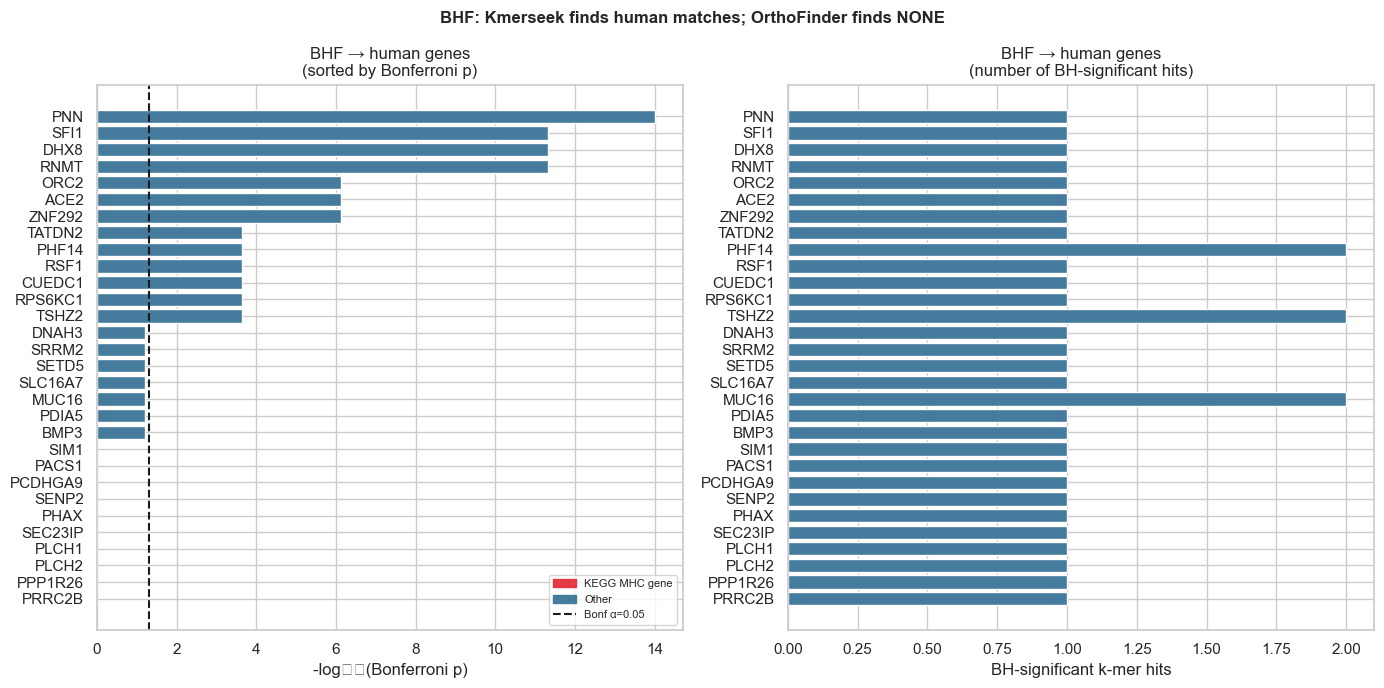

In [11]:
# BHF: Manhattan-style barplot of top matches
top_bhf = bhf_gene_counts.head(30).copy()
top_bhf['neg_log10_bonf'] = -np.log10(top_bhf['min_p_bonf'].clip(lower=1e-300))
colors_bhf = ['#e63946' if m else '#457b9d' for m in top_bhf['is_mhc_kegg']]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
ax.barh(top_bhf['gene_symbol'][::-1], top_bhf['neg_log10_bonf'][::-1], color=colors_bhf[::-1])
ax.axvline(-np.log10(ALPHA), color='k', ls='--', lw=1.5, label=f'Bonferroni α={ALPHA}')
ax.set_xlabel('-log₁₀(Bonferroni p)')
ax.set_title('BHF → human genes\n(sorted by Bonferroni p)')
red_p  = mpatches.Patch(color='#e63946', label='KEGG MHC gene')
blue_p = mpatches.Patch(color='#457b9d', label='Other')
sig_line = plt.Line2D([0],[0], color='k', ls='--', label=f'Bonf α={ALPHA}')
ax.legend(handles=[red_p, blue_p, sig_line], fontsize=8)

ax = axes[1]
ax.barh(top_bhf['gene_symbol'][::-1], top_bhf['n_hits'][::-1], color=colors_bhf[::-1])
ax.set_xlabel('BH-significant k-mer hits')
ax.set_title('BHF → human genes\n(number of BH-significant hits)')

plt.suptitle('BHF: Kmerseek finds human matches; OrthoFinder finds NONE',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

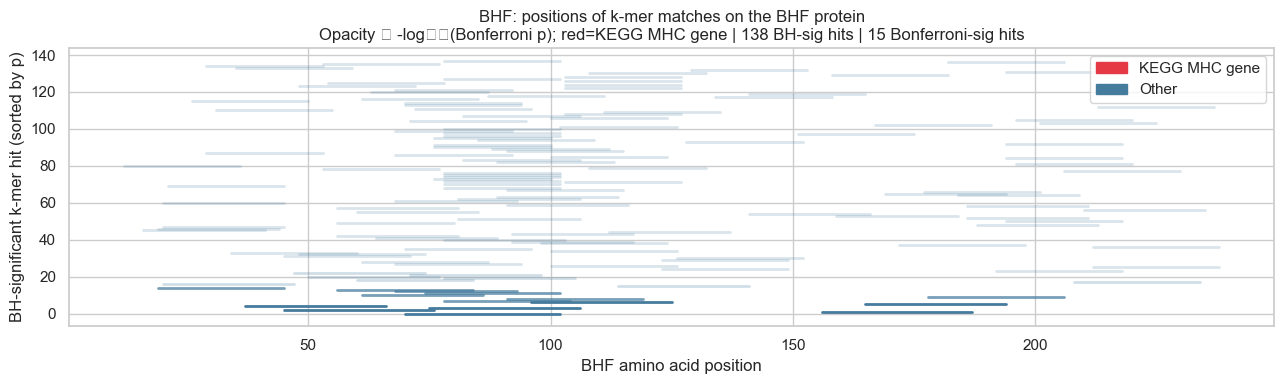

In [12]:
# BHF: positional map of BH-significant hits on the BHF protein sequence
fig, ax = plt.subplots(figsize=(13, max(4, len(bhf_bh) // 50)))

bhf_sorted = bhf_bh.sort_values('poisson_p').reset_index(drop=True)
for i, row in bhf_sorted.iterrows():
    bonf_p    = float(row['poisson_p_bonf'])
    alpha_val = min(1.0, max(0.2, -np.log10(max(bonf_p, 1e-300)) / 5))
    color     = '#e63946' if row['is_mhc_kegg'] else '#457b9d'
    ax.plot([row['query_start'], row['query_end']], [i, i],
            color=color, lw=2, alpha=alpha_val)

bonf_sig_n = (bhf_bh['poisson_p_bonf'] < ALPHA).sum()
ax.set_xlabel('BHF amino acid position')
ax.set_ylabel('BH-significant k-mer hit (sorted by p)')
ax.set_title(
    f'BHF: positions of k-mer matches on the BHF protein\n'
    f'Opacity ∝ -log₁₀(Bonferroni p); '
    f'red=KEGG MHC gene | {len(bhf_bh)} BH-sig hits | {bonf_sig_n} Bonferroni-sig hits'
)
red_p  = mpatches.Patch(color='#e63946', label='KEGG MHC gene')
blue_p = mpatches.Patch(color='#457b9d', label='Other')
ax.legend(handles=[red_p, blue_p])
plt.tight_layout()
plt.show()

## 5. KEGG MHC gene analysis (hsa04612)

In [13]:
mhc_ks = ks[ks['is_mhc_kegg']]
mhc_of = of_pairs[of_pairs['is_mhc_kegg']]

print('=== KEGG MHC genes (hsa04612): Kmerseek (Bonferroni p<0.05) ===')
print(f'  Hits: {len(mhc_ks):,}')
print(f'  Unique MHC genes matched: {mhc_ks["gene_symbol"].nunique():,}')
print(f'  Unique Bs genes with MHC hit: {mhc_ks["query_name"].nunique():,}')
print()
print('=== KEGG MHC genes: OrthoFinder ===')
print(f'  Pairs: {len(mhc_of):,}')
print(f'  Unique MHC genes: {mhc_of["gene_symbol"].nunique():,}')
print(f'  Unique Bs genes: {mhc_of["bs_gene"].nunique():,}')

=== KEGG MHC genes (hsa04612): Kmerseek (Bonferroni p<0.05) ===
  Hits: 5,477
  Unique MHC genes matched: 75
  Unique Bs genes with MHC hit: 1,246

=== KEGG MHC genes: OrthoFinder ===
  Pairs: 765
  Unique MHC genes: 13
  Unique Bs genes: 38


In [14]:
# Which KEGG MHC genes does each method find?
mhc_ks_genes = set(mhc_ks['gene_symbol'].unique())
mhc_of_genes = set(mhc_of['gene_symbol'].unique())

print(f'KEGG MHC genes found ONLY by Kmerseek ({len(mhc_ks_genes - mhc_of_genes)}):')
print(sorted(mhc_ks_genes - mhc_of_genes))
print()
print(f'KEGG MHC genes found ONLY by OrthoFinder ({len(mhc_of_genes - mhc_ks_genes)}):')
print(sorted(mhc_of_genes - mhc_ks_genes))
print()
print(f'KEGG MHC genes found by BOTH ({len(mhc_ks_genes & mhc_of_genes)}):')
print(sorted(mhc_ks_genes & mhc_of_genes))
print()
print(f'KEGG MHC genes found by NEITHER ({len(KEGG_MHC_GENES - mhc_ks_genes - mhc_of_genes)}):')
print(sorted(KEGG_MHC_GENES - mhc_ks_genes - mhc_of_genes))

KEGG MHC genes found ONLY by Kmerseek (62):
['B2M', 'BTNL2', 'CD4', 'CD74', 'CD8A', 'CD8B', 'CD8B2', 'CIITA', 'CTSS', 'HLA-A', 'HLA-B', 'HLA-C', 'HLA-DMA', 'HLA-DMB', 'HLA-DOA', 'HLA-DOB', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DQA1', 'HLA-DQA2', 'HLA-DQB1', 'HLA-DQB2', 'HLA-DRA', 'HLA-DRB1', 'HLA-DRB5', 'HLA-E', 'HLA-F', 'HLA-G', 'HSP90AA1', 'HSPA1B', 'HSPA1L', 'HSPA2', 'HSPA4', 'HSPA6', 'IFNG', 'KIR2DL1', 'KIR2DL3', 'KIR2DL4', 'KIR3DL1', 'KIR3DL2', 'KIR3DL3', 'KLRC1', 'KLRC2', 'KLRC3', 'KLRC4', 'KLRD1', 'MICA', 'MICB', 'NFYA', 'NFYB', 'PSMB8', 'PSMB9', 'PSME1', 'PSME2', 'RFX5', 'RFXANK', 'RFXAP', 'TAP1', 'TAP2', 'TAPBP', 'TAPBPL', 'TNF']

KEGG MHC genes found ONLY by OrthoFinder (0):
[]

KEGG MHC genes found by BOTH (13):
['CALR', 'CANX', 'CREB1', 'CTSB', 'CTSL', 'HSP90AB1', 'HSPA5', 'HSPA8', 'IFI30', 'LGMN', 'NFYC', 'PDIA3', 'PSME3']

KEGG MHC genes found by NEITHER (12):
['HCP5', 'HLA-DRB3', 'HLA-DRB4', 'HSPA1A', 'KIR2DL2', 'KIR2DL5A', 'KIR2DS1', 'KIR2DS2', 'KIR2DS3', 'KIR2DS4', 'KIR2DS5', '

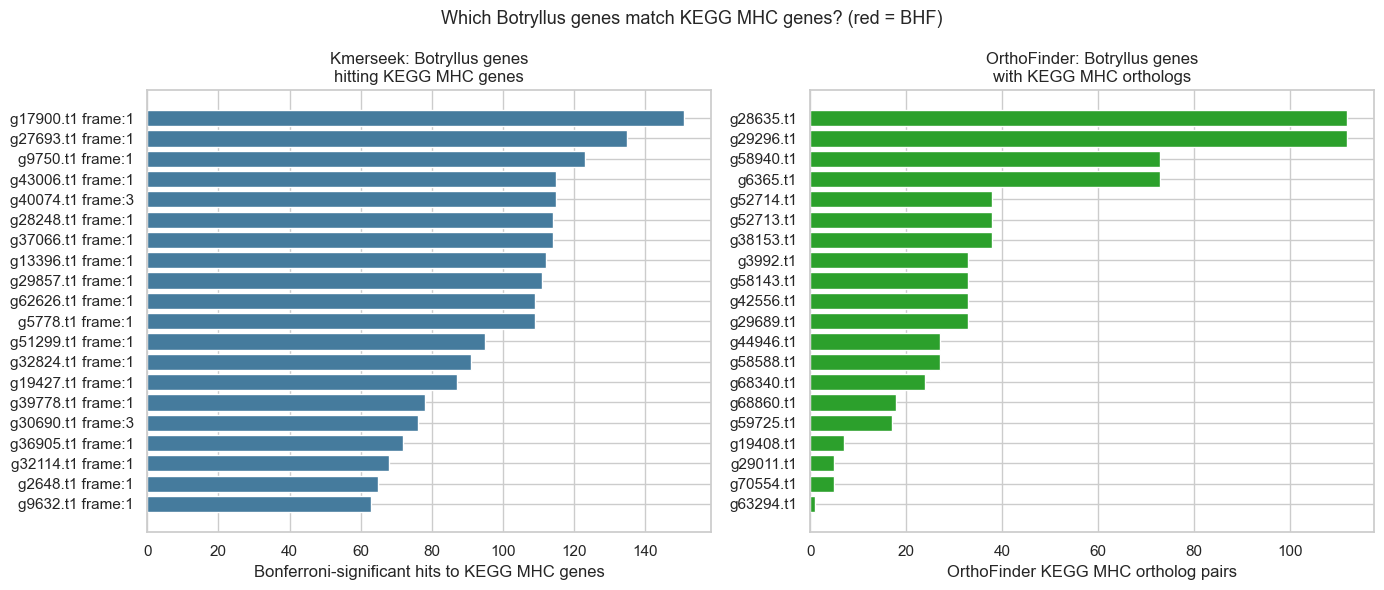

In [15]:
# Which Botryllus genes hit KEGG MHC genes?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
bs_mhc_ks = (mhc_ks.groupby('query_name')
    .agg(n_mhc_genes=('gene_symbol','nunique'), n_hits=('poisson_p_bonf','count'))
    .sort_values('n_hits', ascending=False).head(20))
clr_ks = ['#e63946' if g=='BHF' else '#457b9d' for g in bs_mhc_ks.index]
ax.barh(bs_mhc_ks.index[::-1], bs_mhc_ks['n_hits'][::-1], color=clr_ks[::-1])
ax.set_xlabel('Bonferroni-significant hits to KEGG MHC genes')
ax.set_title('Kmerseek: Botryllus genes\nhitting KEGG MHC genes')

ax = axes[1]
bs_mhc_of = (mhc_of.groupby('bs_gene')
    .agg(n_mhc_genes=('gene_symbol','nunique'), n_pairs=('gene_symbol','count'))
    .sort_values('n_pairs', ascending=False).head(20))
ax.barh(bs_mhc_of.index[::-1], bs_mhc_of['n_pairs'][::-1], color='#2ca02c')
ax.set_xlabel('OrthoFinder KEGG MHC ortholog pairs')
ax.set_title('OrthoFinder: Botryllus genes\nwith KEGG MHC orthologs')

plt.suptitle('Which Botryllus genes match KEGG MHC genes? (red = BHF)', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Top KEGG MHC gene hits (Kmerseek)
mhc_ks_top = (mhc_ks.groupby('gene_symbol')
    .agg(
        n_hits      = ('poisson_p_bonf', 'count'),
        min_p_bonf  = ('poisson_p_bonf', 'min'),
        n_bs_genes  = ('query_name',     'nunique'),
        bs_genes    = ('query_name',     lambda x: ', '.join(sorted(x.unique())[:6])),
    )
    .sort_values('min_p_bonf')
    .reset_index()
)
print('Top KEGG MHC gene hits (Kmerseek, Bonferroni p<0.05):')
mhc_ks_top.head(25)

Top KEGG MHC gene hits (Kmerseek, Bonferroni p<0.05):


,gene_symbol,n_hits,min_p_bonf,n_bs_genes,bs_genes
0,HSPA2,70,1.194755e-293,28,"g10609.t1 frame:1, g15467.t1 frame:2, g1582.t1 frame:1, g18633.t1 frame:1, g19408.t1 frame:1, g20266.t1 frame:1"
1,HSPA5,57,1.194755e-293,30,"g11230.t1 frame:1, g15467.t1 frame:2, g18581.t1 frame:1, g19408.t1 frame:1, g21206.t1 frame:2, g27053.t1 frame:1"
2,HSPA1L,53,1.194755e-293,22,"g10609.t1 frame:1, g15467.t1 frame:2, g1643.t1 frame:1, g17339.t1 frame:1, g1815.t1 frame:1, g19408.t1 frame:1"
3,HSPA1B,62,1.194755e-293,28,"g10609.t1 frame:1, g15467.t1 frame:2, g1643.t1 frame:1, g17339.t1 frame:1, g1815.t1 frame:1, g19408.t1 frame:1"
4,HSP90AB1,79,1.194755e-293,57,"g11825.t1 frame:1, g13087.t1 frame:1, g15536.t1 frame:1, g16037.t1 frame:1, g16037.t2 frame:1, g16037.t3 frame:1"
5,HSP90AA1,95,1.194755e-293,68,"g10383.t1 frame:1, g11016.t1 frame:1, g11663.t1 frame:3, g13538.t1 frame:1, g13899.t1 frame:1, g14414.t1 frame:1"
6,HSPA6,64,1.194755e-293,30,"g10609.t1 frame:1, g15467.t1 frame:2, g1643.t1 frame:1, g17339.t1 frame:1, g1815.t1 frame:1, g19408.t1 frame:1"
7,HSPA8,77,1.194755e-293,37,"g11152.t1 frame:1, g15467.t1 frame:2, g1582.t1 frame:1, g17743.t1 frame:3, g19408.t1 frame:1, g20266.t1 frame:1"
8,CALR,3644,5.204694e-136,174,"g10108.t1 frame:1, g1017.t1 frame:3, g10430.t1 frame:3, g11652.t1 frame:1, g11663.t1 frame:3, g12934.t1 frame:1"
9,HSPA4,72,9.034990e-60,66,"g12632.t1 frame:1, g13892.t1 frame:1, g15038.t1 frame:1, g18089.t1 frame:1, g1820.t1 frame:1, g19171.t1 frame:1"


## 6. Synteny Analysis — Chr6 / MHC region

In [17]:
print('Parsing Gencode v49 GTF for gene coordinates...')
gene_coords = {}
with gzip.open(GENCODE_GTF, 'rt') as f:
    for line in f:
        if line.startswith('#'):
            continue
        fields = line.rstrip().split('\t')
        if len(fields) < 9 or fields[2] != 'gene':
            continue
        chrom, start, end = fields[0], int(fields[3]), int(fields[4])
        attrs  = fields[8]
        ensg_m = re.search(r'gene_id "(ENSG[^"]+)"', attrs)
        sym_m  = re.search(r'gene_name "([^"]+)"', attrs)
        if ensg_m:
            ensg = ensg_m.group(1).split('.')[0]
            gene_coords[ensg] = {'chrom': chrom, 'start': start, 'end': end,
                                  'gtf_symbol': sym_m.group(1) if sym_m else ''}
print(f'Loaded {len(gene_coords):,} gene coordinates.')

coord_df = (pd.DataFrame(gene_coords).T
              .reset_index().rename(columns={'index':'ensg'})
              .astype({'start': int, 'end': int}))

ks_coords = ks.merge(coord_df[['ensg','chrom','start','end']], on='ensg', how='left')
of_coords = of_pairs.merge(coord_df[['ensg','chrom','start','end']], on='ensg', how='left')
print(f'Kmerseek hits with coords: {ks_coords["chrom"].notna().sum():,}/{len(ks_coords):,}')

Parsing Gencode v49 GTF for gene coordinates...


Loaded 78,691 gene coordinates.


Kmerseek hits with coords: 4,528,137/4,528,137


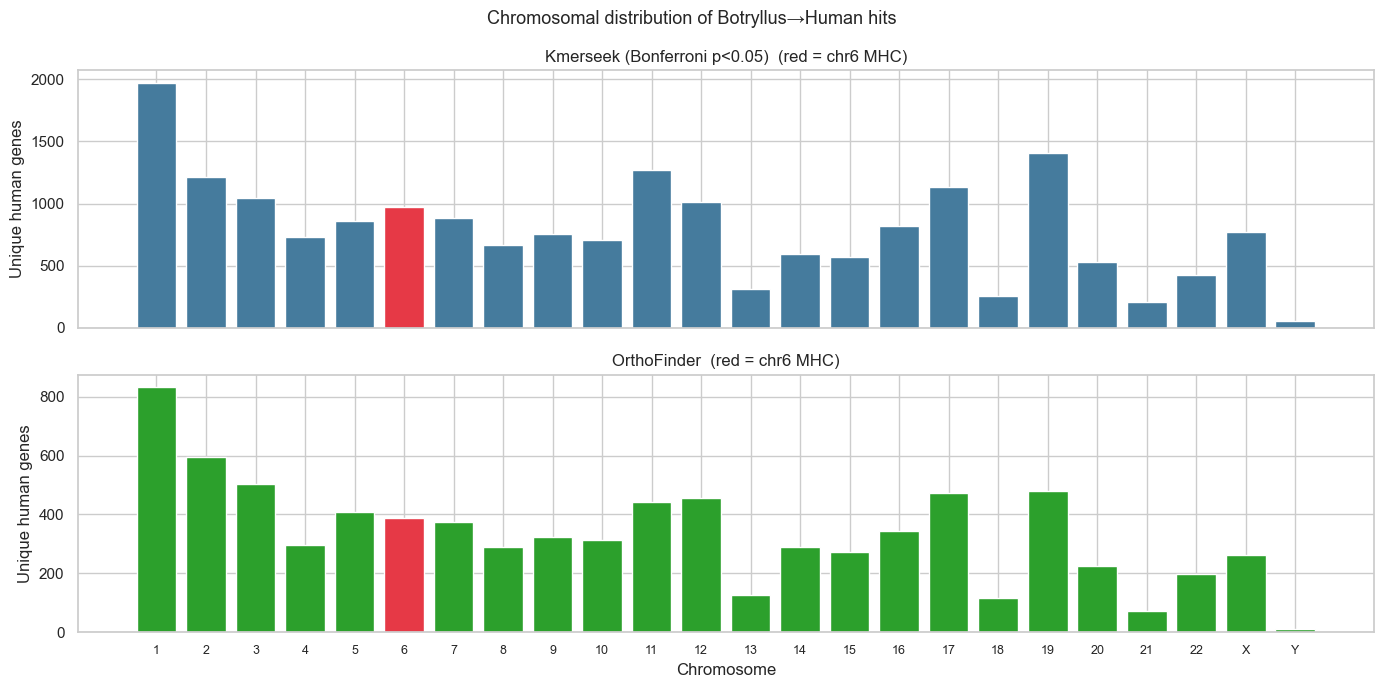

In [18]:
# Chromosomal distribution
std_chroms = [f'chr{i}' for i in range(1, 23)] + ['chrX', 'chrY']

ks_chr = (ks_coords[ks_coords['chrom'].isin(std_chroms)]
          .drop_duplicates('ensg').groupby('chrom').size().reindex(std_chroms, fill_value=0))
of_chr = (of_coords[of_coords['chrom'].isin(std_chroms)]
          .drop_duplicates('ensg').groupby('chrom').size().reindex(std_chroms, fill_value=0))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, counts, title, base_color in [
    (axes[0], ks_chr, 'Kmerseek (Bonferroni p<0.05)', '#457b9d'),
    (axes[1], of_chr, 'OrthoFinder',                  '#2ca02c'),
]:
    clrs = ['#e63946' if c=='chr6' else base_color for c in std_chroms]
    ax.bar(range(len(std_chroms)), counts.values, color=clrs)
    ax.set_ylabel('Unique human genes')
    ax.set_title(f'{title}  (red = chr6 MHC)')

axes[1].set_xticks(range(len(std_chroms)))
axes[1].set_xticklabels([c.replace('chr','') for c in std_chroms], fontsize=9)
axes[1].set_xlabel('Chromosome')
plt.suptitle('Chromosomal distribution of Botryllus→Human hits', fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# Chr6 / MHC region zoom (±2 Mb around the classical MHC)
MHC_START, MHC_END = 28_510_120, 33_480_577
WINDOW = 2_000_000

def in_chr6_window(df, chrom_col='chrom', start_col='start', end_col='end'):
    return df[
        (df[chrom_col] == 'chr6') &
        (df[start_col] >= MHC_START - WINDOW) &
        (df[end_col]   <= MHC_END   + WINDOW)
    ].copy()

chr6_ks = in_chr6_window(ks_coords)
chr6_of = in_chr6_window(of_coords, chrom_col='chrom')

print(f'Chr6/MHC ±2 Mb region:')
print(f'  Kmerseek: {len(chr6_ks):,} hits, '
      f'{chr6_ks["gene_symbol"].nunique():,} genes, '
      f'{chr6_ks["query_name"].nunique():,} Bs genes')
print(f'  OrthoFinder: {len(chr6_of):,} pairs, '
      f'{chr6_of["gene_symbol"].nunique():,} genes, '
      f'{chr6_of["bs_gene"].nunique():,} Bs genes')
print(f'  Botryllus genes with Kmerseek chr6 hits: {sorted(chr6_ks["query_name"].unique())}')

Chr6/MHC ±2 Mb region:
  Kmerseek: 79,883 hits, 231 genes, 5,505 Bs genes
  OrthoFinder: 1,237 pairs, 73 genes, 179 Bs genes
  Botryllus genes with Kmerseek chr6 hits: ['g10002.t1 frame:1', 'g10017.t1 frame:3', 'g10027.t1 frame:1', 'g10067.t1 frame:1', 'g10094.t1 frame:1', 'g10095.t1 frame:1', 'g10099.t1 frame:1', 'g10108.t1 frame:1', 'g10118.t1 frame:1', 'g10119.t1 frame:1', 'g10122.t1 frame:1', 'g10123.t1 frame:1', 'g10132.t1 frame:1', 'g10142.t1 frame:1', 'g10146.t1 frame:1', 'g10156.t1 frame:1', 'g10161.t1 frame:1', 'g1017.t1 frame:3', 'g10173.t1 frame:1', 'g10184.t1 frame:1', 'g10187.t1 frame:1', 'g10191.t1 frame:1', 'g10192.t1 frame:1', 'g1022.t1 frame:1', 'g10225.t1 frame:1', 'g10228.t1 frame:1', 'g10229.t1 frame:1', 'g10233.t1 frame:1', 'g10244.t1 frame:1', 'g10253.t1 frame:1', 'g1026.t1 frame:1', 'g10260.t1 frame:3', 'g10266.t1 frame:1', 'g10271.t1 frame:1', 'g10277.t1 frame:1', 'g10283.t1 frame:1', 'g10308.t1 frame:1', 'g10333.t1 frame:1', 'g10338.t1 frame:1', 'g10351.t1 fram

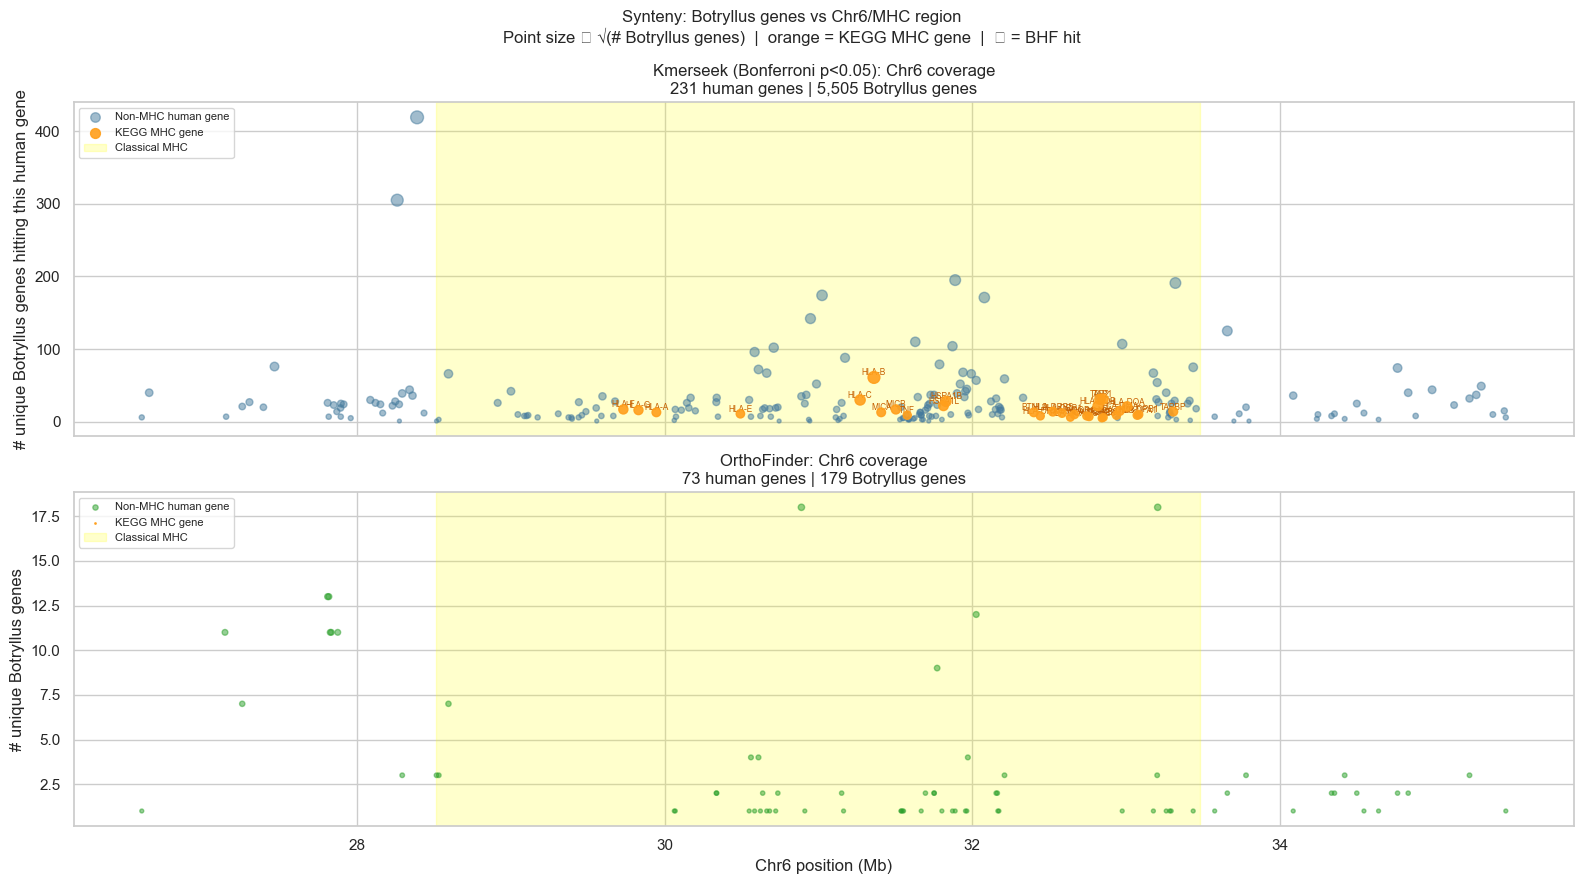

In [20]:
# Synteny plot: human gene positions on chr6, coloured by KEGG MHC, sized by Botryllus coverage
# Each point = one human gene; y = number of unique Botryllus genes hitting it
chr6_ks_gene = (chr6_ks
    .groupby(['gene_symbol','ensg','start','end','is_mhc_kegg'])
    .agg(
        n_bs_genes  = ('query_name', 'nunique'),
        min_p_bonf  = ('poisson_p_bonf', 'min'),
        bhf_hit     = ('query_name', lambda x: 'BHF' in x.values),
    )
    .reset_index()
)
chr6_ks_gene['mid_mb'] = (chr6_ks_gene['start'] + chr6_ks_gene['end']) / 2 / 1e6

chr6_of_gene = (chr6_of
    .groupby(['gene_symbol','ensg','start','end','is_mhc_kegg'])
    .agg(n_bs_genes = ('bs_gene', 'nunique'))
    .reset_index()
)
chr6_of_gene['mid_mb'] = (chr6_of_gene['start'] + chr6_of_gene['end']) / 2 / 1e6

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ── Kmerseek ──
ax = axes[0]
# non-MHC
sub = chr6_ks_gene[~chr6_ks_gene['is_mhc_kegg'] & ~chr6_ks_gene['bhf_hit']]
ax.scatter(sub['mid_mb'], sub['n_bs_genes'],
           s=np.sqrt(sub['n_bs_genes']) * 4 + 4,
           c='#457b9d', alpha=0.5, label='Non-MHC human gene', zorder=2)
# KEGG MHC
sub = chr6_ks_gene[chr6_ks_gene['is_mhc_kegg']]
ax.scatter(sub['mid_mb'], sub['n_bs_genes'],
           s=np.sqrt(sub['n_bs_genes']) * 8 + 10,
           c='#ff9f1c', alpha=0.9, label='KEGG MHC gene', zorder=4)
for _, r in sub.iterrows():
    ax.annotate(r['gene_symbol'], (r['mid_mb'], r['n_bs_genes']),
                fontsize=6, ha='center', va='bottom', color='#c66000')
# BHF-hit human genes
sub = chr6_ks_gene[chr6_ks_gene['bhf_hit']]
if len(sub):
    ax.scatter(sub['mid_mb'], sub['n_bs_genes'],
               s=80, c='#e63946', marker='*', alpha=1.0, label='BHF hit', zorder=5)
    for _, r in sub.iterrows():
        ax.annotate(r['gene_symbol'], (r['mid_mb'], r['n_bs_genes']),
                    fontsize=7, ha='center', va='bottom', color='#e63946', fontweight='bold')
ax.axvspan(MHC_START/1e6, MHC_END/1e6, color='yellow', alpha=0.2, label='Classical MHC')
ax.set_ylabel('# unique Botryllus genes hitting this human gene')
ax.set_title(f'Kmerseek (Bonferroni p<0.05): Chr6 coverage\n'
             f'{chr6_ks_gene["gene_symbol"].nunique()} human genes | '
             f'{chr6_ks["query_name"].nunique():,} Botryllus genes')
ax.legend(fontsize=8, loc='upper left')

# ── OrthoFinder ──
ax = axes[1]
sub = chr6_of_gene[~chr6_of_gene['is_mhc_kegg']]
ax.scatter(sub['mid_mb'], sub['n_bs_genes'],
           s=np.sqrt(sub['n_bs_genes']) * 4 + 4,
           c='#2ca02c', alpha=0.5, label='Non-MHC human gene', zorder=2)
sub = chr6_of_gene[chr6_of_gene['is_mhc_kegg']]
ax.scatter(sub['mid_mb'], sub['n_bs_genes'],
           s=np.sqrt(sub['n_bs_genes']) * 8 + 10,
           c='#ff9f1c', alpha=0.9, label='KEGG MHC gene', zorder=4)
for _, r in sub.iterrows():
    ax.annotate(r['gene_symbol'], (r['mid_mb'], r['n_bs_genes']),
                fontsize=6, ha='center', va='bottom', color='#c66000')
ax.axvspan(MHC_START/1e6, MHC_END/1e6, color='yellow', alpha=0.2, label='Classical MHC')
ax.set_xlabel('Chr6 position (Mb)')
ax.set_ylabel('# unique Botryllus genes')
ax.set_title(f'OrthoFinder: Chr6 coverage\n'
             f'{chr6_of_gene["gene_symbol"].nunique()} human genes | '
             f'{chr6_of["bs_gene"].nunique():,} Botryllus genes')
ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Synteny: Botryllus genes vs Chr6/MHC region\n'
             'Point size ∝ √(# Botryllus genes)  |  orange = KEGG MHC gene  |  ★ = BHF hit',
             fontsize=12)
plt.tight_layout()
plt.show()

## 6b. Synteny Dotplot — Human Chr6 × Botryllus Genome

In [21]:

# ── Parse Botryllus GTF → gene coordinates ────────────────────────────────────
BS_GTF = '/Users/olga/data/botryllus/transcripts30GTF.gtf'

bs_gene_min = {}  # gene_id → {'chrom', 'start', 'end'}
with open(BS_GTF) as f:
    for line in f:
        if line.startswith('#'):
            continue
        fields = line.rstrip().split('\t')
        if len(fields) < 9:
            continue
        chrom, start, end = fields[0], int(fields[3]), int(fields[4])
        m = re.search(r'gene_id "([^"]+)"', fields[8])
        if not m:
            continue
        gid = m.group(1)
        if gid not in bs_gene_min:
            bs_gene_min[gid] = {'chrom': chrom, 'start': start, 'end': end}
        else:
            bs_gene_min[gid]['start'] = min(bs_gene_min[gid]['start'], start)
            bs_gene_min[gid]['end']   = max(bs_gene_min[gid]['end'],   end)

bs_coords_df = pd.DataFrame(bs_gene_min).T.reset_index().rename(columns={'index': 'bs_gene_id'})
bs_coords_df = bs_coords_df.astype({'start': int, 'end': int})
print(f'Botryllus genes with coordinates: {len(bs_coords_df):,}')
print(bs_coords_df.groupby('chrom').size().to_string())


Botryllus genes with coordinates: 43,590
chrom
chr1       858
chr10     1838
chr11      254
chr12     1494
chr13     1283
chr2       634
chr3       170
chr4       852
chr5      2571
chr6       867
chr7      1253
chr8       223
chr9      1797
chrUn    29496


Chr6 hits passing Bonferroni p<0.05: 198,361  (20,831 Botryllus, 969 human genes)


Human chr6 genes plotted: 897
Botryllus genes (chr1-13) plotted: 4,961
Unique pairs: 7,909  (KEGG MHC: 146)


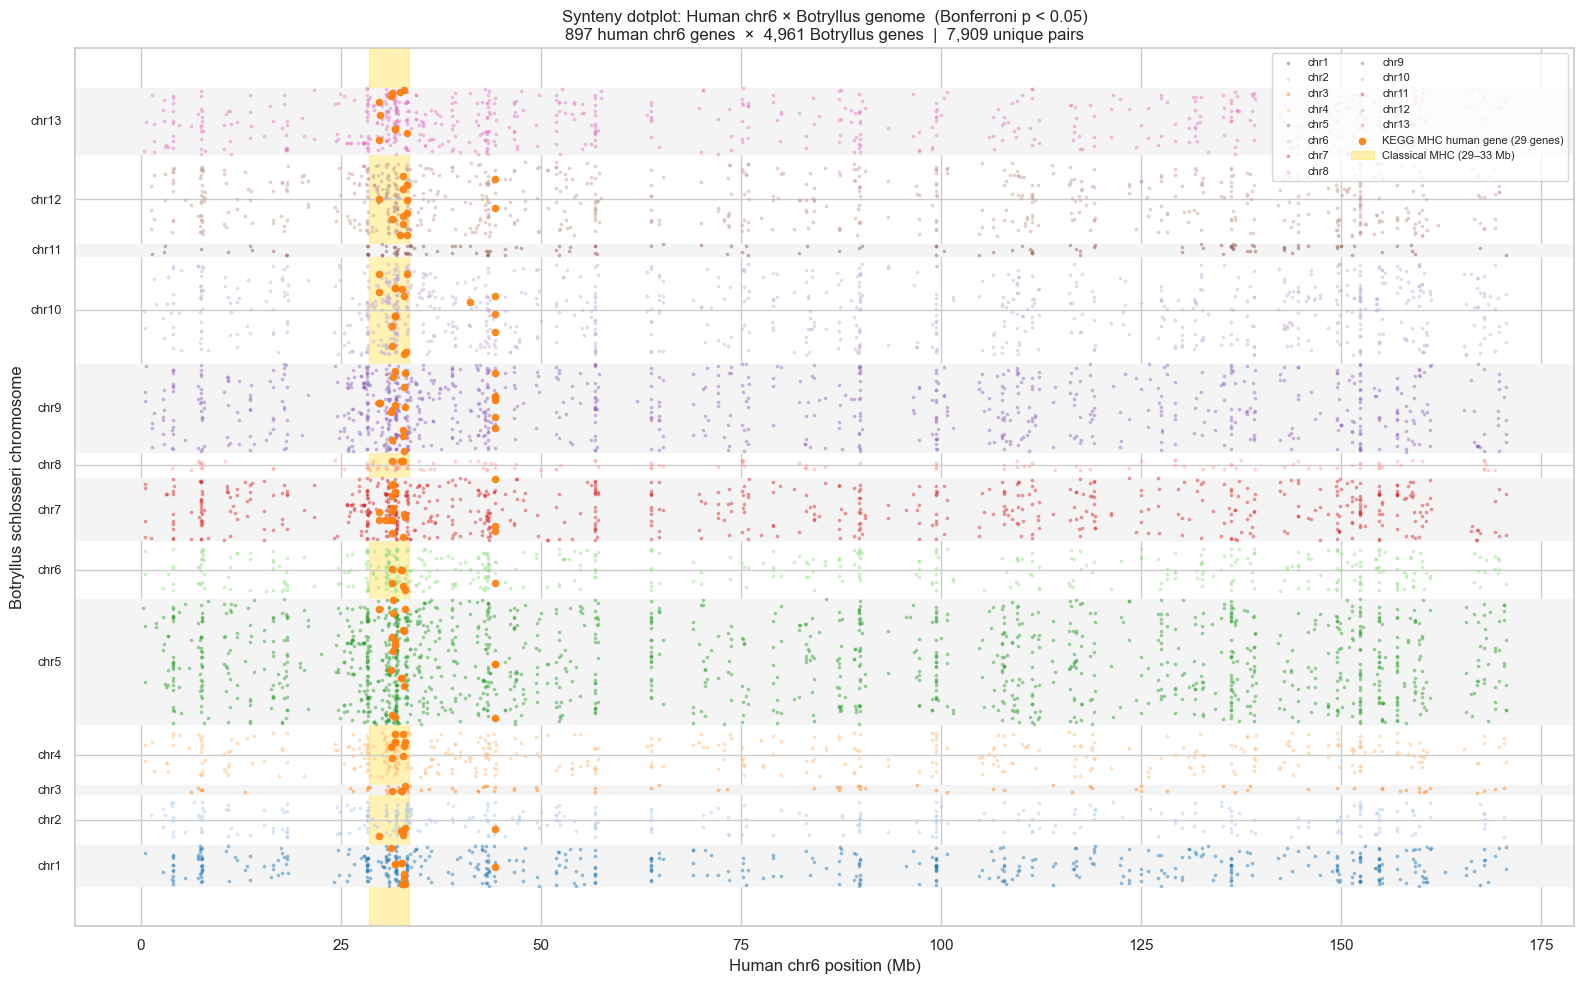

Saved dotplot_chr6_vs_botryllus.png


In [22]:

# ── Synteny dotplot: human chr6 × Botryllus genome ────────────────────────────
# X axis: human chr6 position (Mb)
# Y axis: Botryllus chromosomal position (Mb), chromosomes stacked chr1→chr13
# One dot per unique (human gene, botryllus gene) pair with Bonferroni p < 0.05

BS_CHROMS_ORDERED = [f'chr{i}' for i in range(1, 14)]  # skip chrUn (407 Mb, unassembled)

# Chromosome sizes from GTF
bs_chrom_sizes = {c: int(bs_coords_df[bs_coords_df['chrom'] == c]['end'].max())
                  for c in BS_CHROMS_ORDERED
                  if c in bs_coords_df['chrom'].values}

# Cumulative Y offsets for stacking chromosomes
GAP = 2_000_000
bs_chrom_offset = {}
offset = 0
for c in BS_CHROMS_ORDERED:
    if c in bs_chrom_sizes:
        bs_chrom_offset[c] = offset
        offset += bs_chrom_sizes[c] + GAP

# ── Extract base gene_id from kmerseek query_name ─────────────────────────────
def extract_bs_gene_id(qname):
    s = re.sub(r'\s+frame:\d+$', '', str(qname).strip())
    s = re.sub(r'\.t\d+$', '', s)
    return s

# Explicit Bonferroni filter + chr6 human genes
ks_chr6 = ks_coords[
    (ks_coords['chrom'] == 'chr6') &
    (ks_coords['poisson_p_bonf'] < ALPHA)
].copy()
print(f'Chr6 hits passing Bonferroni p<{ALPHA}: {len(ks_chr6):,}  '
      f'({ks_chr6["query_name"].nunique():,} Botryllus, '
      f'{ks_chr6["gene_symbol"].nunique():,} human genes)')

ks_chr6['bs_gene_id'] = ks_chr6['query_name'].map(extract_bs_gene_id)

# Merge with Botryllus gene coordinates (inner join)
ks_dotplot = ks_chr6.merge(
    bs_coords_df[['bs_gene_id', 'chrom', 'start', 'end']].rename(
        columns={'chrom': 'bs_chrom', 'start': 'bs_start', 'end': 'bs_end'}),
    on='bs_gene_id', how='inner'
)
ks_dotplot = ks_dotplot[ks_dotplot['bs_chrom'].isin(BS_CHROMS_ORDERED)].copy()

# Positions in Mb (vectorized)
ks_dotplot['human_mb'] = (ks_dotplot['start'] + ks_dotplot['end']) / 2 / 1e6
offset_series = ks_dotplot['bs_chrom'].map(bs_chrom_offset)
ks_dotplot['bs_cum_mb'] = (offset_series + (ks_dotplot['bs_start'] + ks_dotplot['bs_end']) / 2) / 1e6

# Deduplicate: one dot per (human gene, botryllus gene) pair
dp = (ks_dotplot
      .groupby(['ensg', 'gene_symbol', 'bs_gene_id', 'bs_chrom',
                'human_mb', 'bs_cum_mb', 'is_mhc_kegg'])
      .agg(min_p_bonf=('poisson_p_bonf', 'min'))
      .reset_index())

# Final explicit filter (guaranteed, but makes intent clear)
dp = dp[dp['min_p_bonf'] < ALPHA].copy()

print(f'Human chr6 genes plotted: {dp["ensg"].nunique():,}')
print(f'Botryllus genes (chr1-13) plotted: {dp["bs_gene_id"].nunique():,}')
print(f'Unique pairs: {len(dp):,}  (KEGG MHC: {dp["is_mhc_kegg"].sum():,})')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))

palette = plt.cm.tab20.colors
chrom_colors = {c: palette[i % 20] for i, c in enumerate(BS_CHROMS_ORDERED)}

# Alternating chromosome shading
for i, c in enumerate(BS_CHROMS_ORDERED):
    if c not in bs_chrom_offset:
        continue
    ylo = bs_chrom_offset[c] / 1e6
    yhi = (bs_chrom_offset[c] + bs_chrom_sizes[c]) / 1e6
    if i % 2 == 0:
        ax.axhspan(ylo, yhi, color='#f4f4f4', zorder=1)

# Dots coloured by Botryllus chromosome
for chrom in BS_CHROMS_ORDERED:
    sub = dp[(dp['bs_chrom'] == chrom) & ~dp['is_mhc_kegg']]
    if len(sub):
        ax.scatter(sub['human_mb'], sub['bs_cum_mb'],
                   s=3, c=[chrom_colors[chrom]], alpha=0.35, rasterized=True, zorder=2,
                   label=chrom)

# KEGG MHC human gene pairs on top (orange)
sub_mhc = dp[dp['is_mhc_kegg']]
if len(sub_mhc):
    ax.scatter(sub_mhc['human_mb'], sub_mhc['bs_cum_mb'],
               s=20, c='#ff7f0e', alpha=0.9, zorder=5,
               label=f'KEGG MHC human gene ({sub_mhc["ensg"].nunique()} genes)')

# Highlight classical MHC region on X axis
ax.axvspan(MHC_START / 1e6, MHC_END / 1e6, color='gold', alpha=0.3, zorder=0,
           label=f'Classical MHC ({MHC_START/1e6:.0f}–{MHC_END/1e6:.0f} Mb)')

# Y-axis chromosome ticks
ytick_pos, ytick_labels = [], []
for c in BS_CHROMS_ORDERED:
    if c in bs_chrom_offset and c in bs_chrom_sizes:
        mid = (bs_chrom_offset[c] + bs_chrom_sizes[c] / 2) / 1e6
        ytick_pos.append(mid)
        ytick_labels.append(c)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels, fontsize=9)

ax.set_xlabel('Human chr6 position (Mb)', fontsize=12)
ax.set_ylabel('Botryllus schlosseri chromosome', fontsize=12)
ax.set_title(
    f'Synteny dotplot: Human chr6 × Botryllus genome  (Bonferroni p < {ALPHA})\n'
    f'{dp["ensg"].nunique():,} human chr6 genes  ×  '
    f'{dp["bs_gene_id"].nunique():,} Botryllus genes  |  {len(dp):,} unique pairs',
    fontsize=12
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, fontsize=8, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig('dotplot_chr6_vs_botryllus.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved dotplot_chr6_vs_botryllus.png')


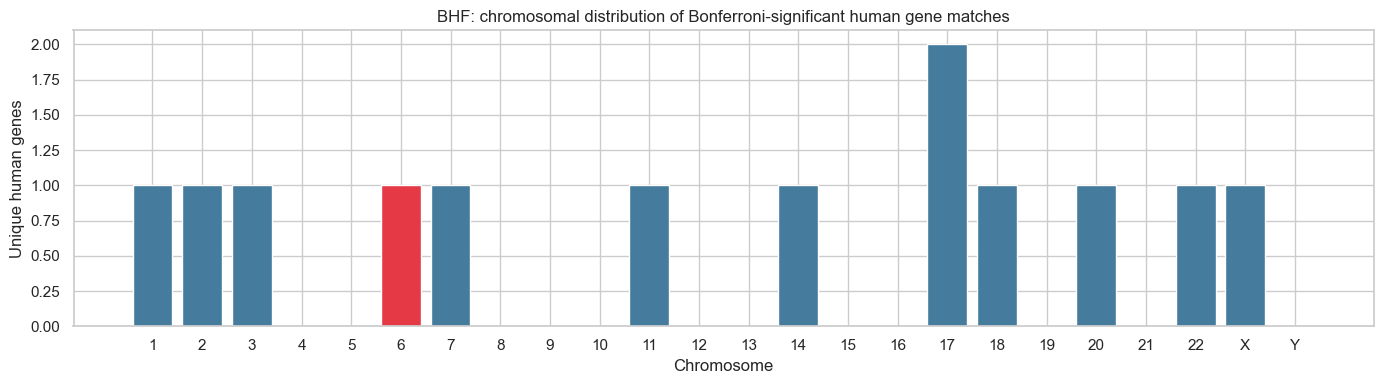

chrom
chr1     1
chr2     1
chr3     1
chr6     1
chr7     1
chr11    1
chr14    1
chr17    2
chr18    1
chr20    1
chr22    1
chrX     1


In [23]:
# BHF genome-wide distribution
bhf_coords = ks_coords[ks_coords['query_name']=='BHF'].dropna(subset=['chrom'])
bhf_std    = bhf_coords[bhf_coords['chrom'].isin(std_chroms)].drop_duplicates('ensg')
bhf_chr    = bhf_std.groupby('chrom').size().reindex(std_chroms, fill_value=0)

if len(bhf_std) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    clrs = ['#e63946' if c=='chr6' else '#457b9d' for c in std_chroms]
    ax.bar(range(len(std_chroms)), bhf_chr.values, color=clrs)
    ax.set_xticks(range(len(std_chroms)))
    ax.set_xticklabels([c.replace('chr','') for c in std_chroms])
    ax.set_xlabel('Chromosome')
    ax.set_ylabel('Unique human genes')
    ax.set_title('BHF: chromosomal distribution of Bonferroni-significant human gene matches')
    plt.tight_layout(); plt.show()
    print(bhf_chr[bhf_chr > 0].to_string())
else:
    print('No Bonferroni-significant BHF hits with chr coordinates.')
    print('(BHF has BH-significant hits but none survive Bonferroni.)')

## 7. Summary

In [24]:
bs_only_ks = sorted(bs_ks - bs_of)
ks_only_df = (ks[ks['query_name'].isin(bs_only_ks)]
    .groupby('query_name')
    .agg(
        n_human_genes = ('gene_symbol', 'nunique'),
        n_hits        = ('poisson_p_bonf', 'count'),
        min_p_bonf    = ('poisson_p_bonf', 'min'),
        n_mhc_hits    = ('is_mhc_kegg', 'sum'),
    )
    .sort_values('n_human_genes', ascending=False)
    .reset_index()
)
print(f'Botryllus genes with Kmerseek hits but NO OrthoFinder ortholog: {len(bs_only_ks):,}')
print(f'  Includes BHF: {"BHF" in bs_only_ks}')
print('\nTop 20:')
ks_only_df.head(20)

Botryllus genes with Kmerseek hits but NO OrthoFinder ortholog: 68,604
  Includes BHF: True

Top 20:


,query_name,n_human_genes,n_hits,min_p_bonf,n_mhc_hits
0,g37114.t1 frame:3,299,14611,1.684902e-138,18
1,g17900.t1 frame:1,287,128115,8.351015e-94,151
2,g30690.t1 frame:3,277,53716,2.249915e-83,76
3,g20912.t1 frame:1,261,35397,5.729746e-75,47
4,g36905.t1 frame:1,257,59348,6.417353e-76,72
5,g32736.t1 frame:1,255,7528,4.202751e-143,8
6,g60344.t1 frame:1,245,28035,1.872954e-78,33
7,g51299.t1 frame:1,245,85726,6.671383e-70,95
8,g9750.t1 frame:1,245,97928,3.500416e-77,123
9,g64774.t1 frame:3,244,33670,1.737877e-86,41


In [25]:
print('=' * 65)
print('SUMMARY: Kmerseek (Bonferroni) vs OrthoFinder — Botryllus/Human')
print('=' * 65)
print(f'Bonferroni threshold: {ALPHA}/{N_TOTAL:,} = {BONF_THRESHOLD:.2e}')
print(f'MHC gene set: KEGG hsa04612 ({len(KEGG_MHC_GENES)} genes)')
print()
print('Kmerseek (Bonferroni p<0.05):')
print(f'  Significant hits:          {len(ks):>10,}')
print(f'  Botryllus genes matched:   {n_bs_ks:>10,}')
print(f'  Human genes matched:       {n_hu_ks:>10,}')
print(f'  KEGG MHC gene hits:        {ks["is_mhc_kegg"].sum():>10,}')
print(f'  KEGG MHC genes matched:    {mhc_ks["gene_symbol"].nunique():>10,}')
print()
print('OrthoFinder:')
print(f'  Gene pairs:                {len(of_pairs):>10,}')
print(f'  Botryllus genes matched:   {n_bs_of:>10,}')
print(f'  Human genes matched:       {n_hu_of:>10,}')
print(f'  KEGG MHC gene pairs:       {of_pairs["is_mhc_kegg"].sum():>10,}')
print(f'  KEGG MHC genes matched:    {mhc_of["gene_symbol"].nunique():>10,}')
print()
print('BHF (Botryllus Histocompatibility Factor):')
print(f'  OrthoFinder:               NO human ortholog (orphan orthogroup)')
print(f'  Kmerseek BH p<0.05:        {len(bhf_bh):>10,} hits  '
      f'({bhf_bh["is_mhc_kegg"].sum()} KEGG MHC)')
print(f'  Kmerseek Bonferroni p<0.05:{len(bhf_bonf):>10,} hits')
print()
print(f'Kmerseek-only (no OrthoFinder ortholog): {len(bs_only_ks):,} Bs genes')

SUMMARY: Kmerseek (Bonferroni) vs OrthoFinder — Botryllus/Human
Bonferroni threshold: 0.05/11,947,553 = 4.18e-09
MHC gene set: KEGG hsa04612 (87 genes)

Kmerseek (Bonferroni p<0.05):
  Significant hits:           4,528,137
  Botryllus genes matched:       68,604
  Human genes matched:           19,181
  KEGG MHC gene hits:             5,477
  KEGG MHC genes matched:            75

OrthoFinder:
  Gene pairs:                   166,383
  Botryllus genes matched:       19,333
  Human genes matched:            8,288
  KEGG MHC gene pairs:              765
  KEGG MHC genes matched:            13

BHF (Botryllus Histocompatibility Factor):
  OrthoFinder:               NO human ortholog (orphan orthogroup)
  Kmerseek BH p<0.05:               138 hits  (0 KEGG MHC)
  Kmerseek Bonferroni p<0.05:        15 hits

Kmerseek-only (no OrthoFinder ortholog): 68,604 Bs genes
